<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/data_mining_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

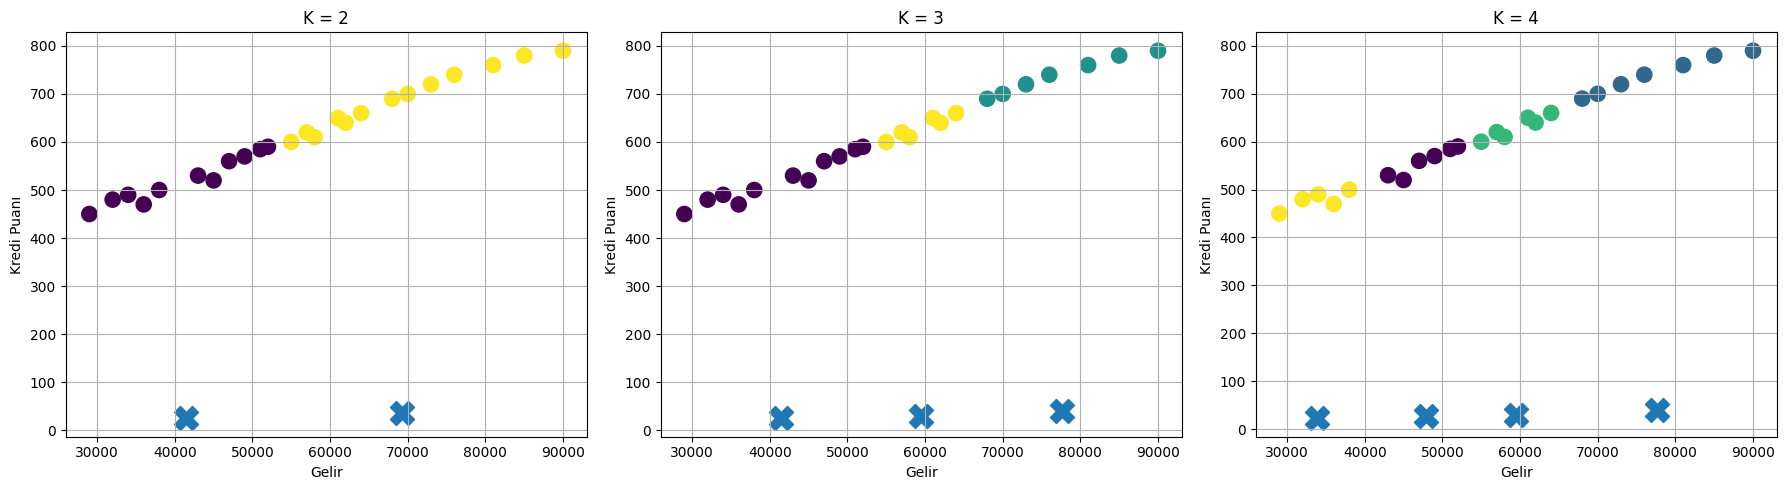

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Veri seti
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)

# Ölçekleme (çok önemli)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# K değerleri
k_values = [2, 3, 4]

plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    df[f"cluster_{k}"] = kmeans.fit_predict(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(df["gelir"], df["kredi_puani"], c=df[f"cluster_{k}"], s=120)

    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=300)

    plt.title(f"K = {k}")
    plt.xlabel("Gelir")
    plt.ylabel("Kredi Puanı")
    plt.grid(True)

plt.tight_layout()
plt.show()

SONUÇLARIN ANALİZİ
K = 2 (İki küme)
Yapı:
Küme 1 → düşük gelir + düşük kredi puanı
Küme 2 → yüksek gelir + yüksek kredi puanı
Yorum:
Çok genel segmentasyon
Risk vs güvenli ayrımı yapılır
Ama detay yok

İş karşılığı:

“riskli müşteriler”
“iyi müşteriler”

Basit ama yetersiz

K = 3 (Üç küme)
Yapı:
Küme 1 → düşük segment
Küme 2 → orta segment
Küme 3 → yüksek segment
Yorum:
En dengeli dağılım
Gerçek hayata en yakın segmentasyon

İş karşılığı:

düşük risk
orta risk
premium müşteri

EN DOĞRU MODEL

K = 4 (Dört küme)
Yapı:
Segmentler fazla bölünmüş
Bazı kümeler anlamsız küçük gruplar oluşturur
Yorum:
Over-segmentation (aşırı parçalama)
İş açısından gereksiz detay

Fazla karmaşık

Elbow Methodu:

Grafikte şunu görürsün:

K=1 → çok kötü
K=2 → ciddi iyileşme
K=3 → hala iyi iyileşme
K=4 → artık az iyileşme

***Dirsek noktası: K = 3

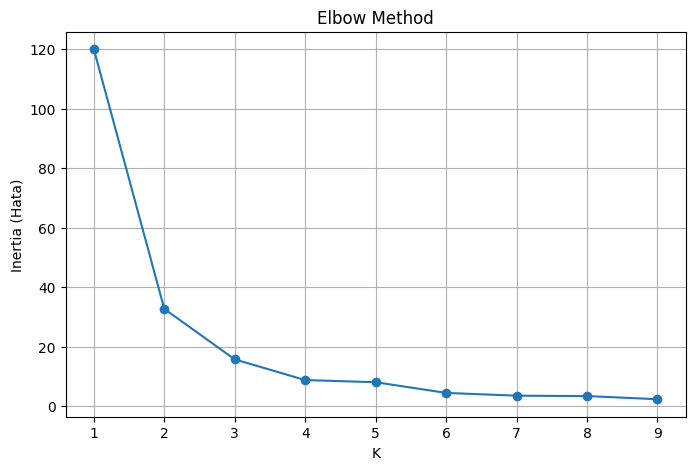

In [3]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia (Hata)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Bu veri seti üzerinde gerçekleştirilen kümeleme analizinde K=2, K=3 ve K=4 değerleri karşılaştırılmıştır. K=2 durumunda veri yalnızca iki ana gruba ayrılmış ve detaylı segmentasyon elde edilememiştir. K=4 durumunda ise veri aşırı bölünerek bazı kümelerin anlamlılığını yitirdiği gözlemlenmiştir. K=3 değeri ise veri setinin doğal yapısını en iyi temsil eden, dengeli ve yorumlanabilir segmentler oluşturmuştur.

Elbow yöntemi kullanılarak yapılan analizde de K=3 noktasında dirsek oluştuğu görülmüş ve bu değer optimal küme sayısı olarak belirlenmiştir.

Sonuç olarak, bu veri seti için en uygun küme sayısı K=3 olarak seçilmiştir.

İŞ ZEKÂSI YORUMU (EN ÖNEMLİ KISIM)

K=3 için segmentler:

Küme 0 → Riskli müşteriler (Açlar)
düşük gelir
düşük kredi puanı
kredi verilmemeli / düşük limit (versen geri alamazsın)

Küme 1 → Orta segment (orta direk)
orta gelir
orta kredi puanı
kontrollü kredi  (gelirine göre kredi ver)

Küme 2 → Boynu Kalın müşteriler
yüksek gelir
yüksek kredi puanı
yüksek limit / özel teklifler (Boyun kalınlığına göre daha fazla teklif ver) :)